In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

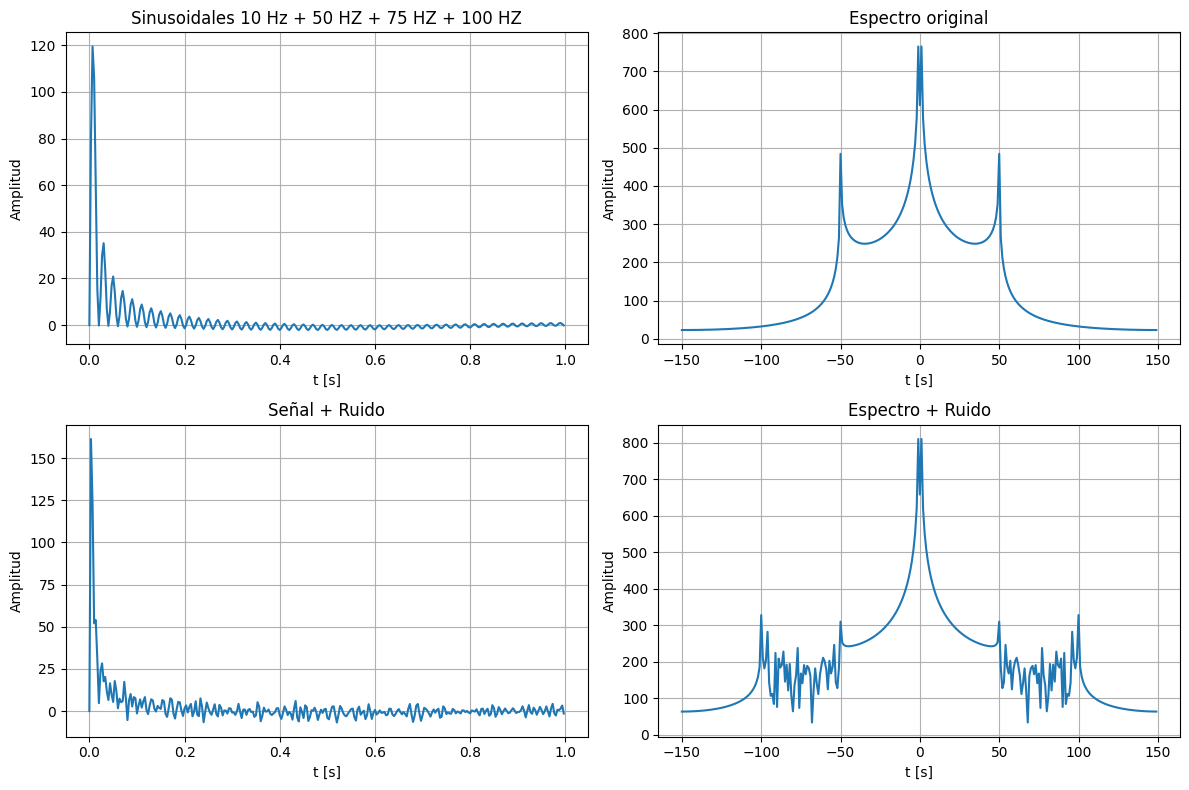

In [8]:
def generar_senoidal(N, frecs, frecM, std=None):
    # N = n° segundos
    Tm = 1/frecM

    dom = np.arange(0, N, Tm)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(dom * 2 * np.pi * frecs[f])
        if std is not None:
            senoidal *= np.random.rand() * std

        senoidal_final += senoidal
    
    
    return dom, senoidal_final

frecM = 300
duracion = 1
std = 5
dom, seno_comb = generar_senoidal(duracion, np.arange(1,50,0.3), frecM)
_, ruido = generar_senoidal(duracion, np.arange(51, 100, 0.3), frecM, 1)
seno_comb_ruido = seno_comb + ruido

fft_seno_comb = np.fft.fft(seno_comb, frecM*duracion)
norm_seno_comb = np.abs(fft_seno_comb)

fft_frecs = np.fft.fftfreq(frecM*duracion, 1/frecM)
shift_frecs = np.fft.fftshift(fft_frecs)
shift_seno_comb = np.fft.fftshift(norm_seno_comb)

ruido_fft_sc = np.fft.fft(seno_comb_ruido, frecM * duracion)
norm_ruido_sc = np.abs(ruido_fft_sc)
shift_norm_ruido = np.fft.fftshift(norm_ruido_sc)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Sinusoidales 10 Hz + 50 HZ + 75 HZ + 100 HZ")
plt.plot(dom, seno_comb)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(2,2,2)
plt.title("Espectro original")
plt.plot(shift_frecs, shift_seno_comb)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.grid(True)


plt.subplot(2,2,3)
plt.title("Señal + Ruido")
plt.plot(dom, seno_comb_ruido)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(2,2,4)
plt.title("Espectro + Ruido")
plt.plot(shift_frecs, shift_norm_ruido)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

d:\Facultad\Año 4 Cuatri 1\Procesamiento digital de señales\TPS\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Facultad\Año 4 Cuatri 1\Procesamiento digital de señales\TPS\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


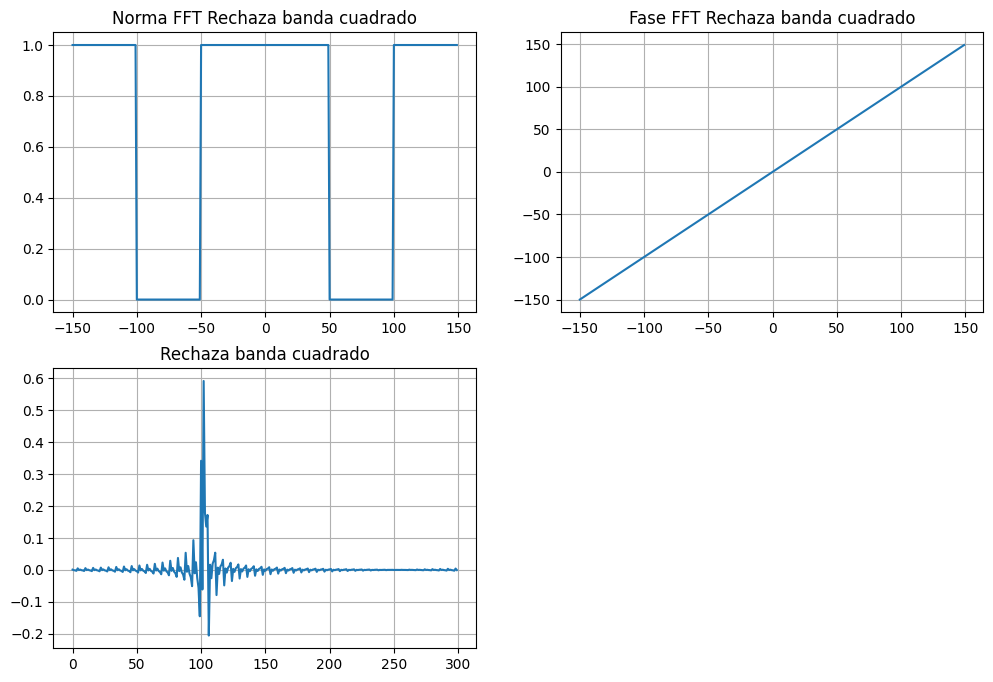

In [ ]:
rc_frecs = np.fft.fftfreq(len(seno_comb_ruido), 1/frecM)

norm_rub_cuadrado = np.logical_or(
    np.abs(rc_frecs) < 50,
    np.abs(rc_frecs) > 100 
)

shift_rc = np.fft.fftshift(norm_rub_cuadrado)
shift_frecs_rc = np.fft.fftshift(rc_frecs)

fase_rub_cuadrado = 1 * rc_frecs.copy()
shift_fase_rc = np.fft.fftshift(fase_rub_cuadrado)
H_cuad = norm_rub_cuadrado * np.exp(1j * fase_rub_cuadrado)
h_cuad = np.fft.ifft(H_cuad)
shift_h_cuad = np.fft.fftshift(h_cuad)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Norma FFT Rechaza banda cuadrado")
plt.plot(shift_frecs_rc, shift_rc)
plt.grid()

plt.subplot(2,2,2)
plt.title("Fase FFT Rechaza banda cuadrado")
plt.plot(shift_frecs_rc, shift_fase_rc)
plt.grid()

plt.subplot(2,2,3)
plt.title("Rechaza banda cuadrado")
plt.plot(shift_h_cuad)
plt.grid()

plt.show()

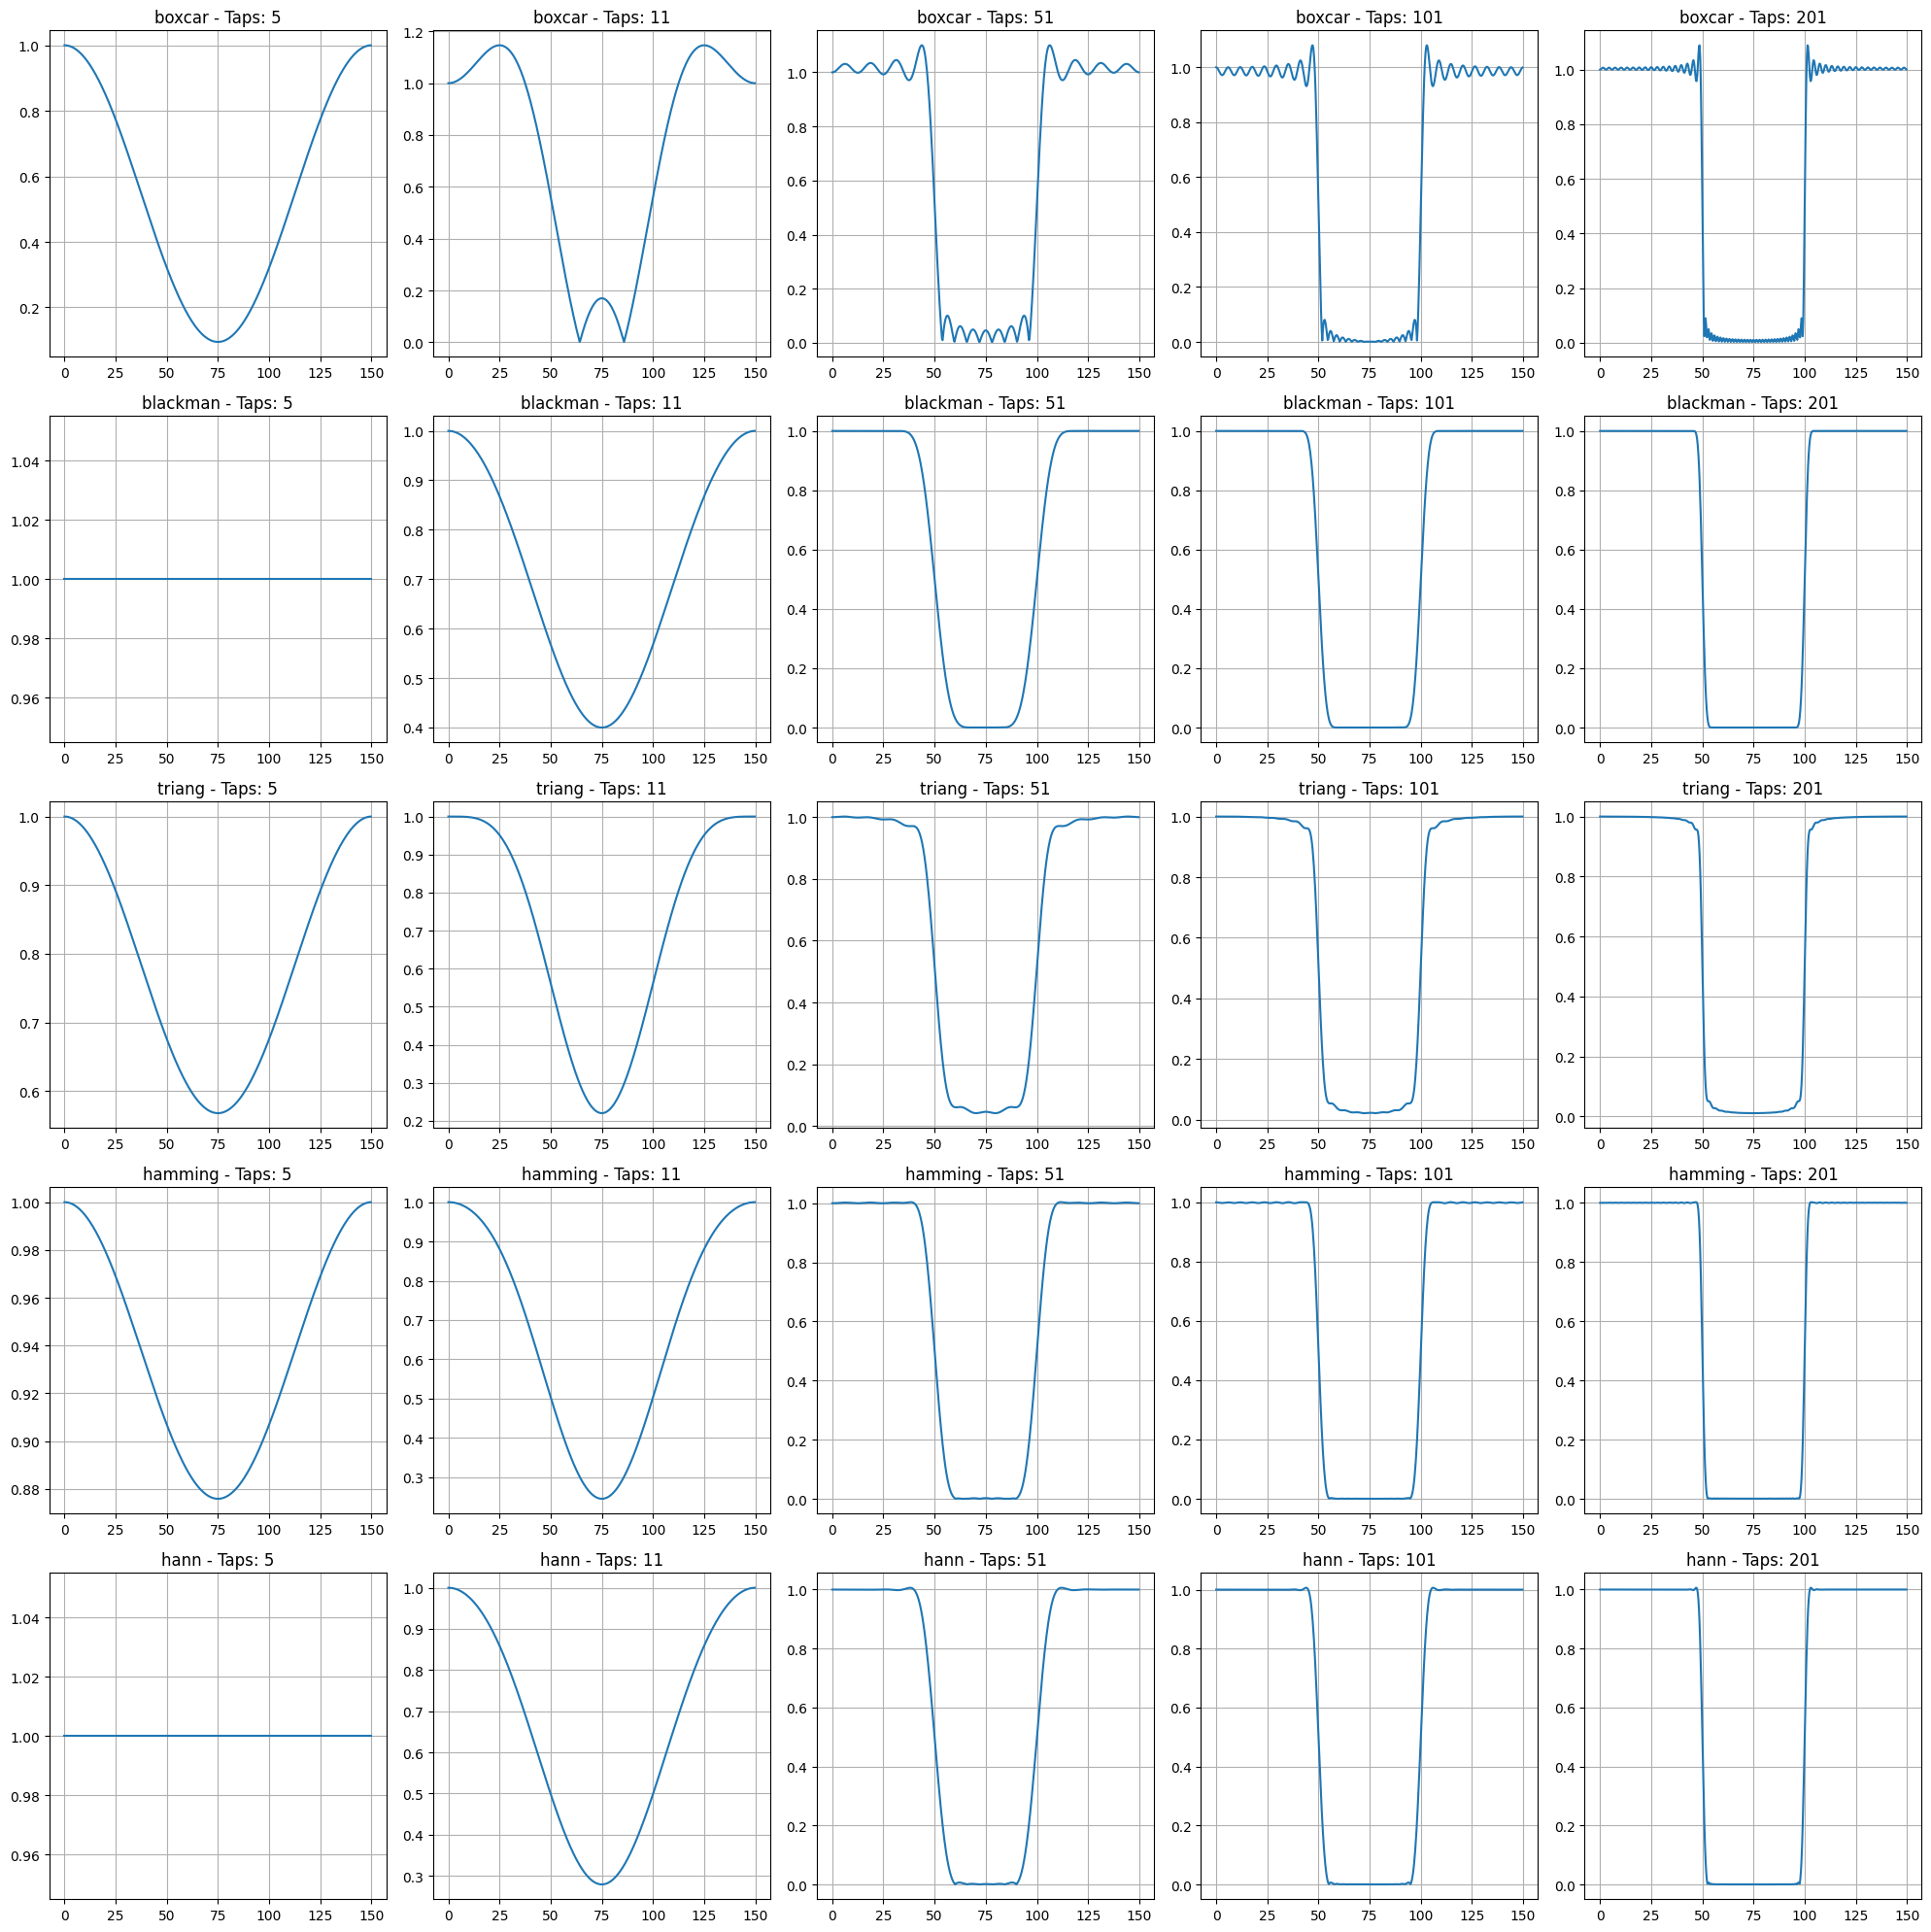

In [42]:
# NOTA: Ajusta la frecuencia de muestreo (fs) a la que estés usando en tu proyecto
fs = frecM

Ordenes = [5, 10, 50, 100, 200]
# En scipy, la ventana cuadrada se llama 'boxcar'
ventanas = ['boxcar', 'blackman', 'triang', 'hamming', 'hann']

filtros_temporales = []

plt.figure(figsize=(20, 20))

for i in range(len(ventanas)):
    ventana_nom = ventanas[i]
    
    for j in range(len(Ordenes)):
        orden = Ordenes[j]
        
        # 1. Ajuste matemático CRÍTICO para filtros Rechaza Banda:
        # Los filtros rechaza banda DEBEN tener un número impar de coeficientes (taps).
        # Taps = orden + 1. Si el orden es impar (ej. 5), los taps son pares (6), lo cual falla.
        numtaps = orden
        if numtaps % 2 == 0:
            numtaps += 1  # Forzamos que el número de taps sea impar
            
        # 2. Diseño del filtro con firwin
        # pasamos las frecuencias de corte [50, 100]. 
        # pass_zero=True indica que deja pasar las frecuencias bajas (0 Hz), es decir, es Rechaza Banda.
        taps = signal.firwin(numtaps, [50, 100], fs=fs, window=ventana_nom, pass_zero=True)

        # 3. Calculamos la respuesta en frecuencia directamente usando freqz
        # w son las frecuencias, h es la respuesta compleja
        w, H = signal.freqz(taps, fs=fs)
        h = np.fft.ifft(H, frecM*duracion)
        shift_h = np.fft.fftshift(h)
        filtros_temporales.append(shift_h)

        # Obtenemos la magnitud
        mag = np.abs(H)

        # Graficamos
        plt.subplot(len(ventanas), len(Ordenes), i * len(Ordenes) + j + 1)
        plt.title(f"{ventana_nom} - Taps: {numtaps}")
        plt.plot(w, mag)
        plt.grid(True)

plt.tight_layout()
plt.show()

d:\Facultad\Año 4 Cuatri 1\Procesamiento digital de señales\TPS\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Facultad\Año 4 Cuatri 1\Procesamiento digital de señales\TPS\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


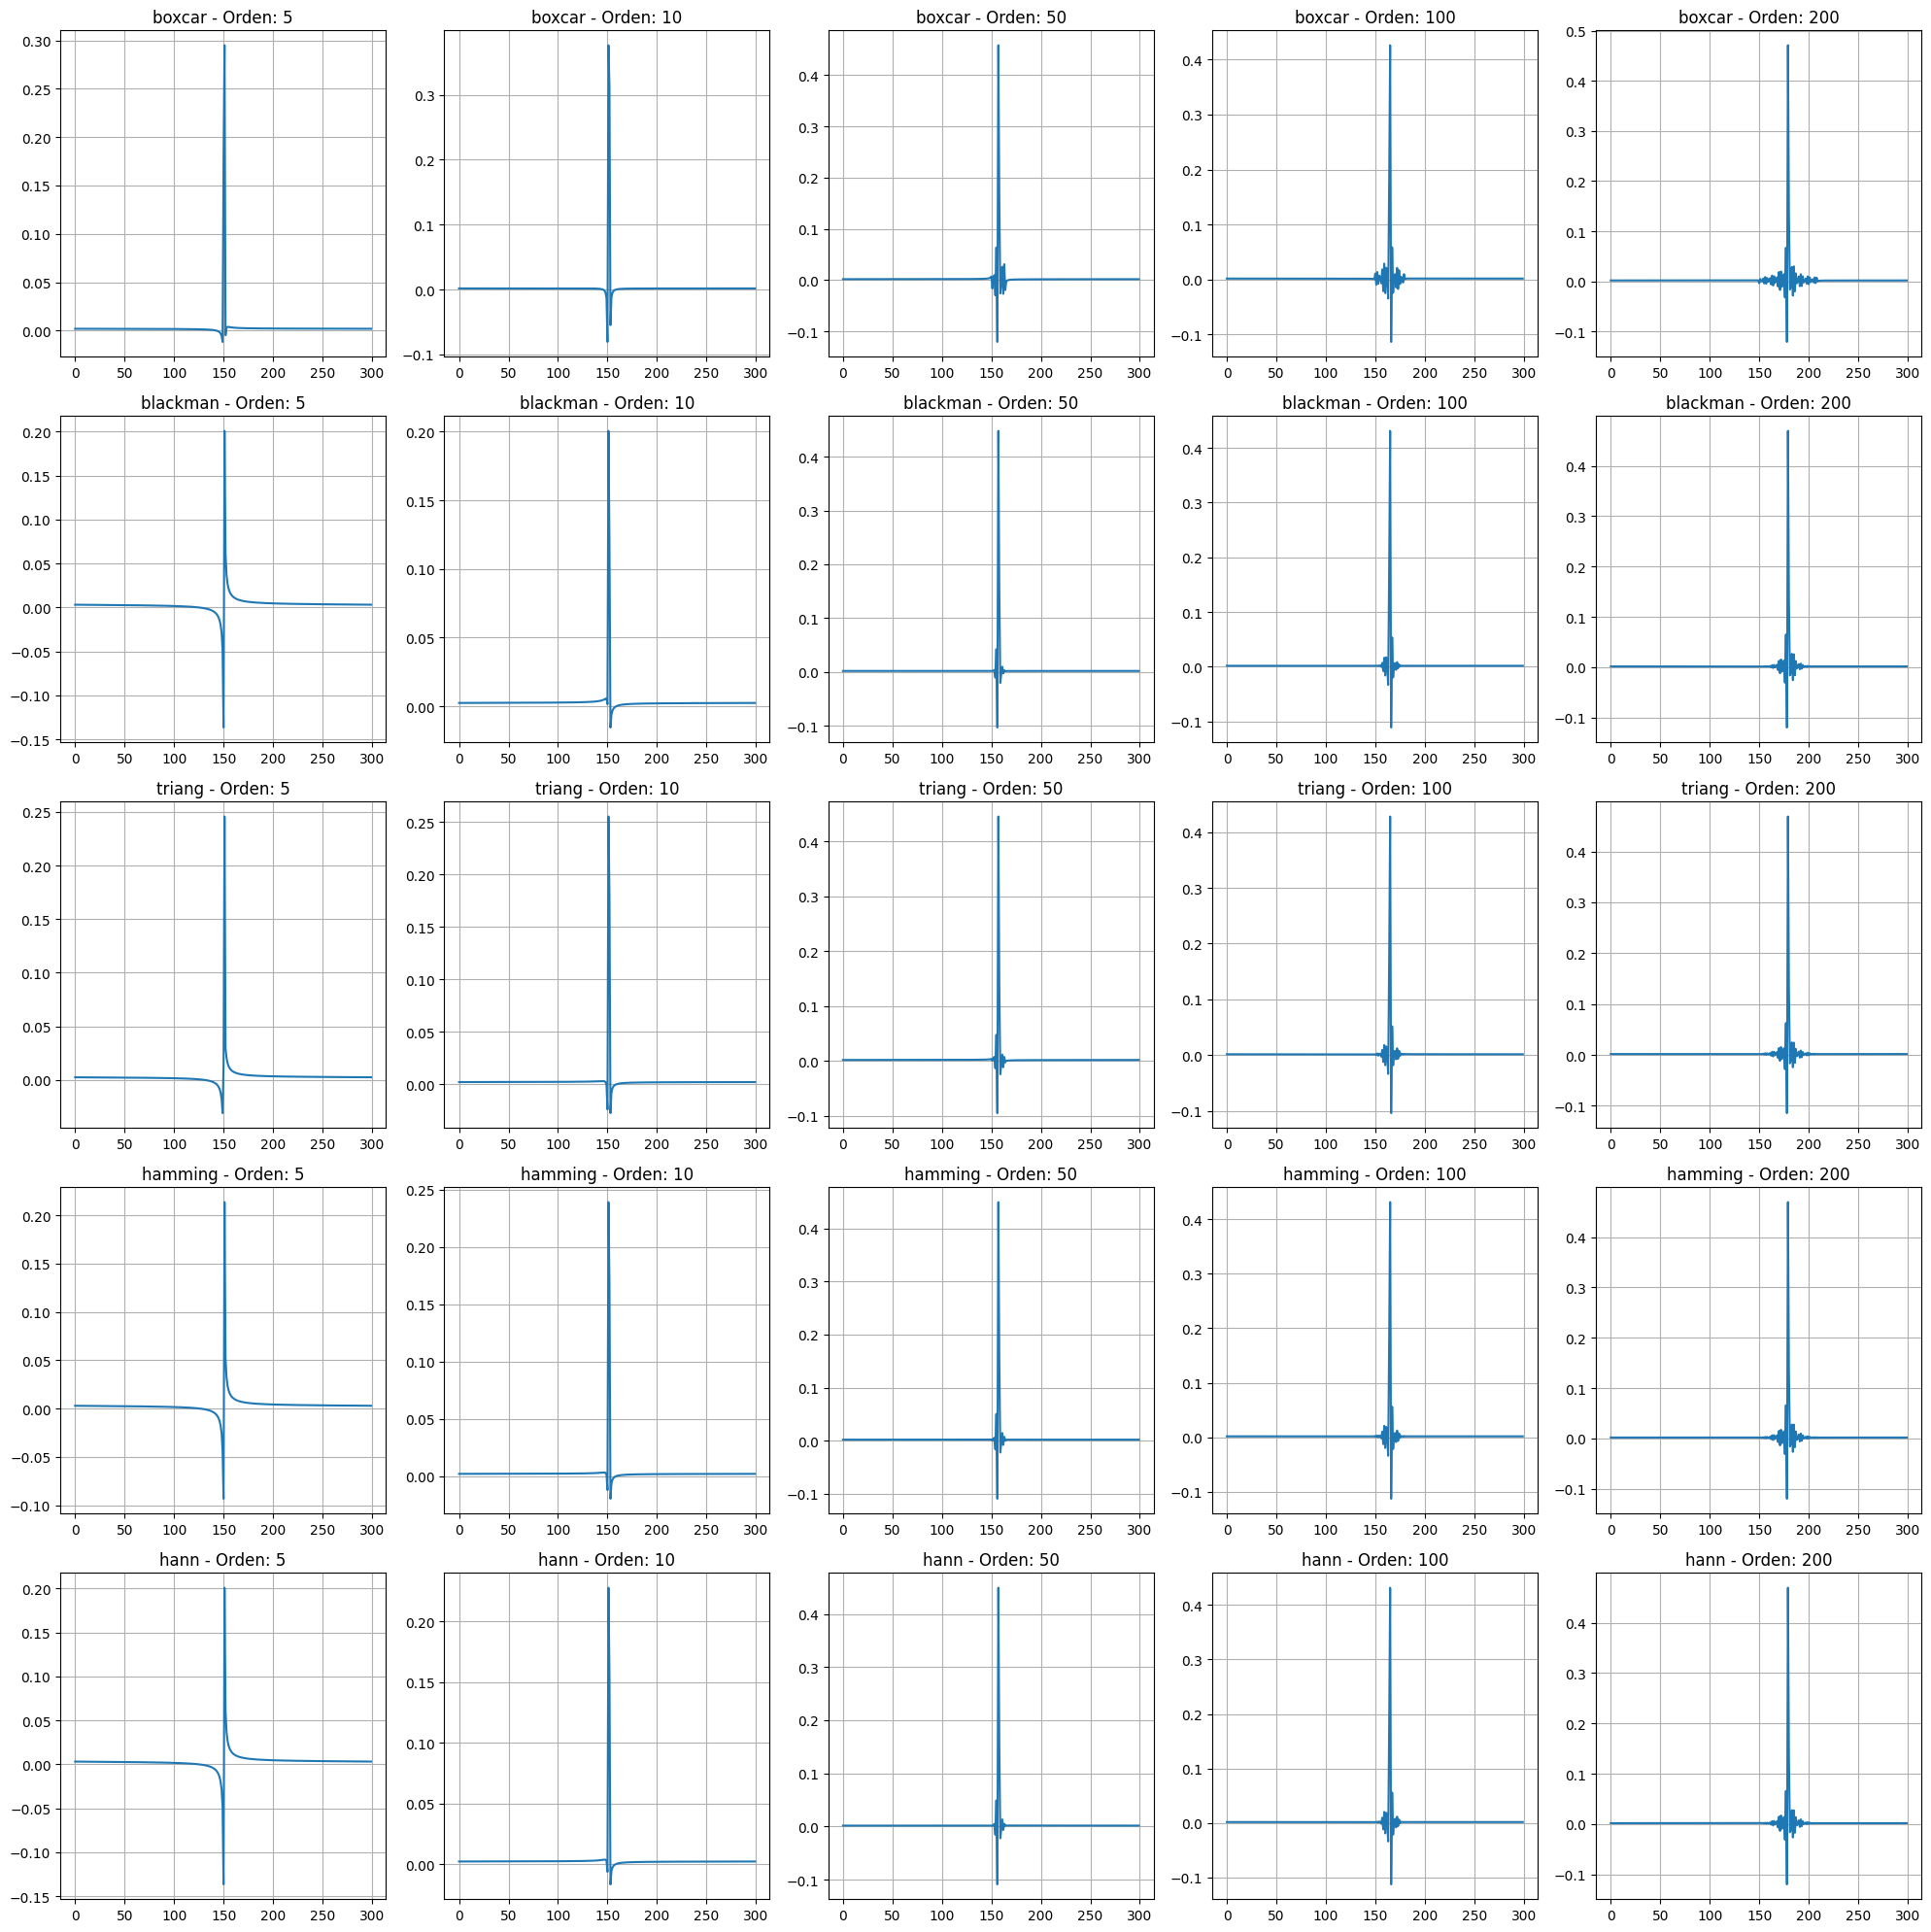

In [45]:
plt.figure(figsize=(20, 20))

for i in range(len(ventanas)):
    ventana_nom = ventanas[i]
    
    for j in range(len(Ordenes)):
        orden = Ordenes[j]
        
        filtro = filtros_temporales[i*len(Ordenes) + j]

        # Graficamos
        plt.subplot(len(ventanas), len(Ordenes), i * len(Ordenes) + j + 1)
        plt.title(f"{ventana_nom} - Orden: {orden}")
        plt.plot(filtro)
        plt.grid(True)

plt.tight_layout()
plt.show()

d:\Facultad\Año 4 Cuatri 1\Procesamiento digital de señales\TPS\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Facultad\Año 4 Cuatri 1\Procesamiento digital de señales\TPS\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


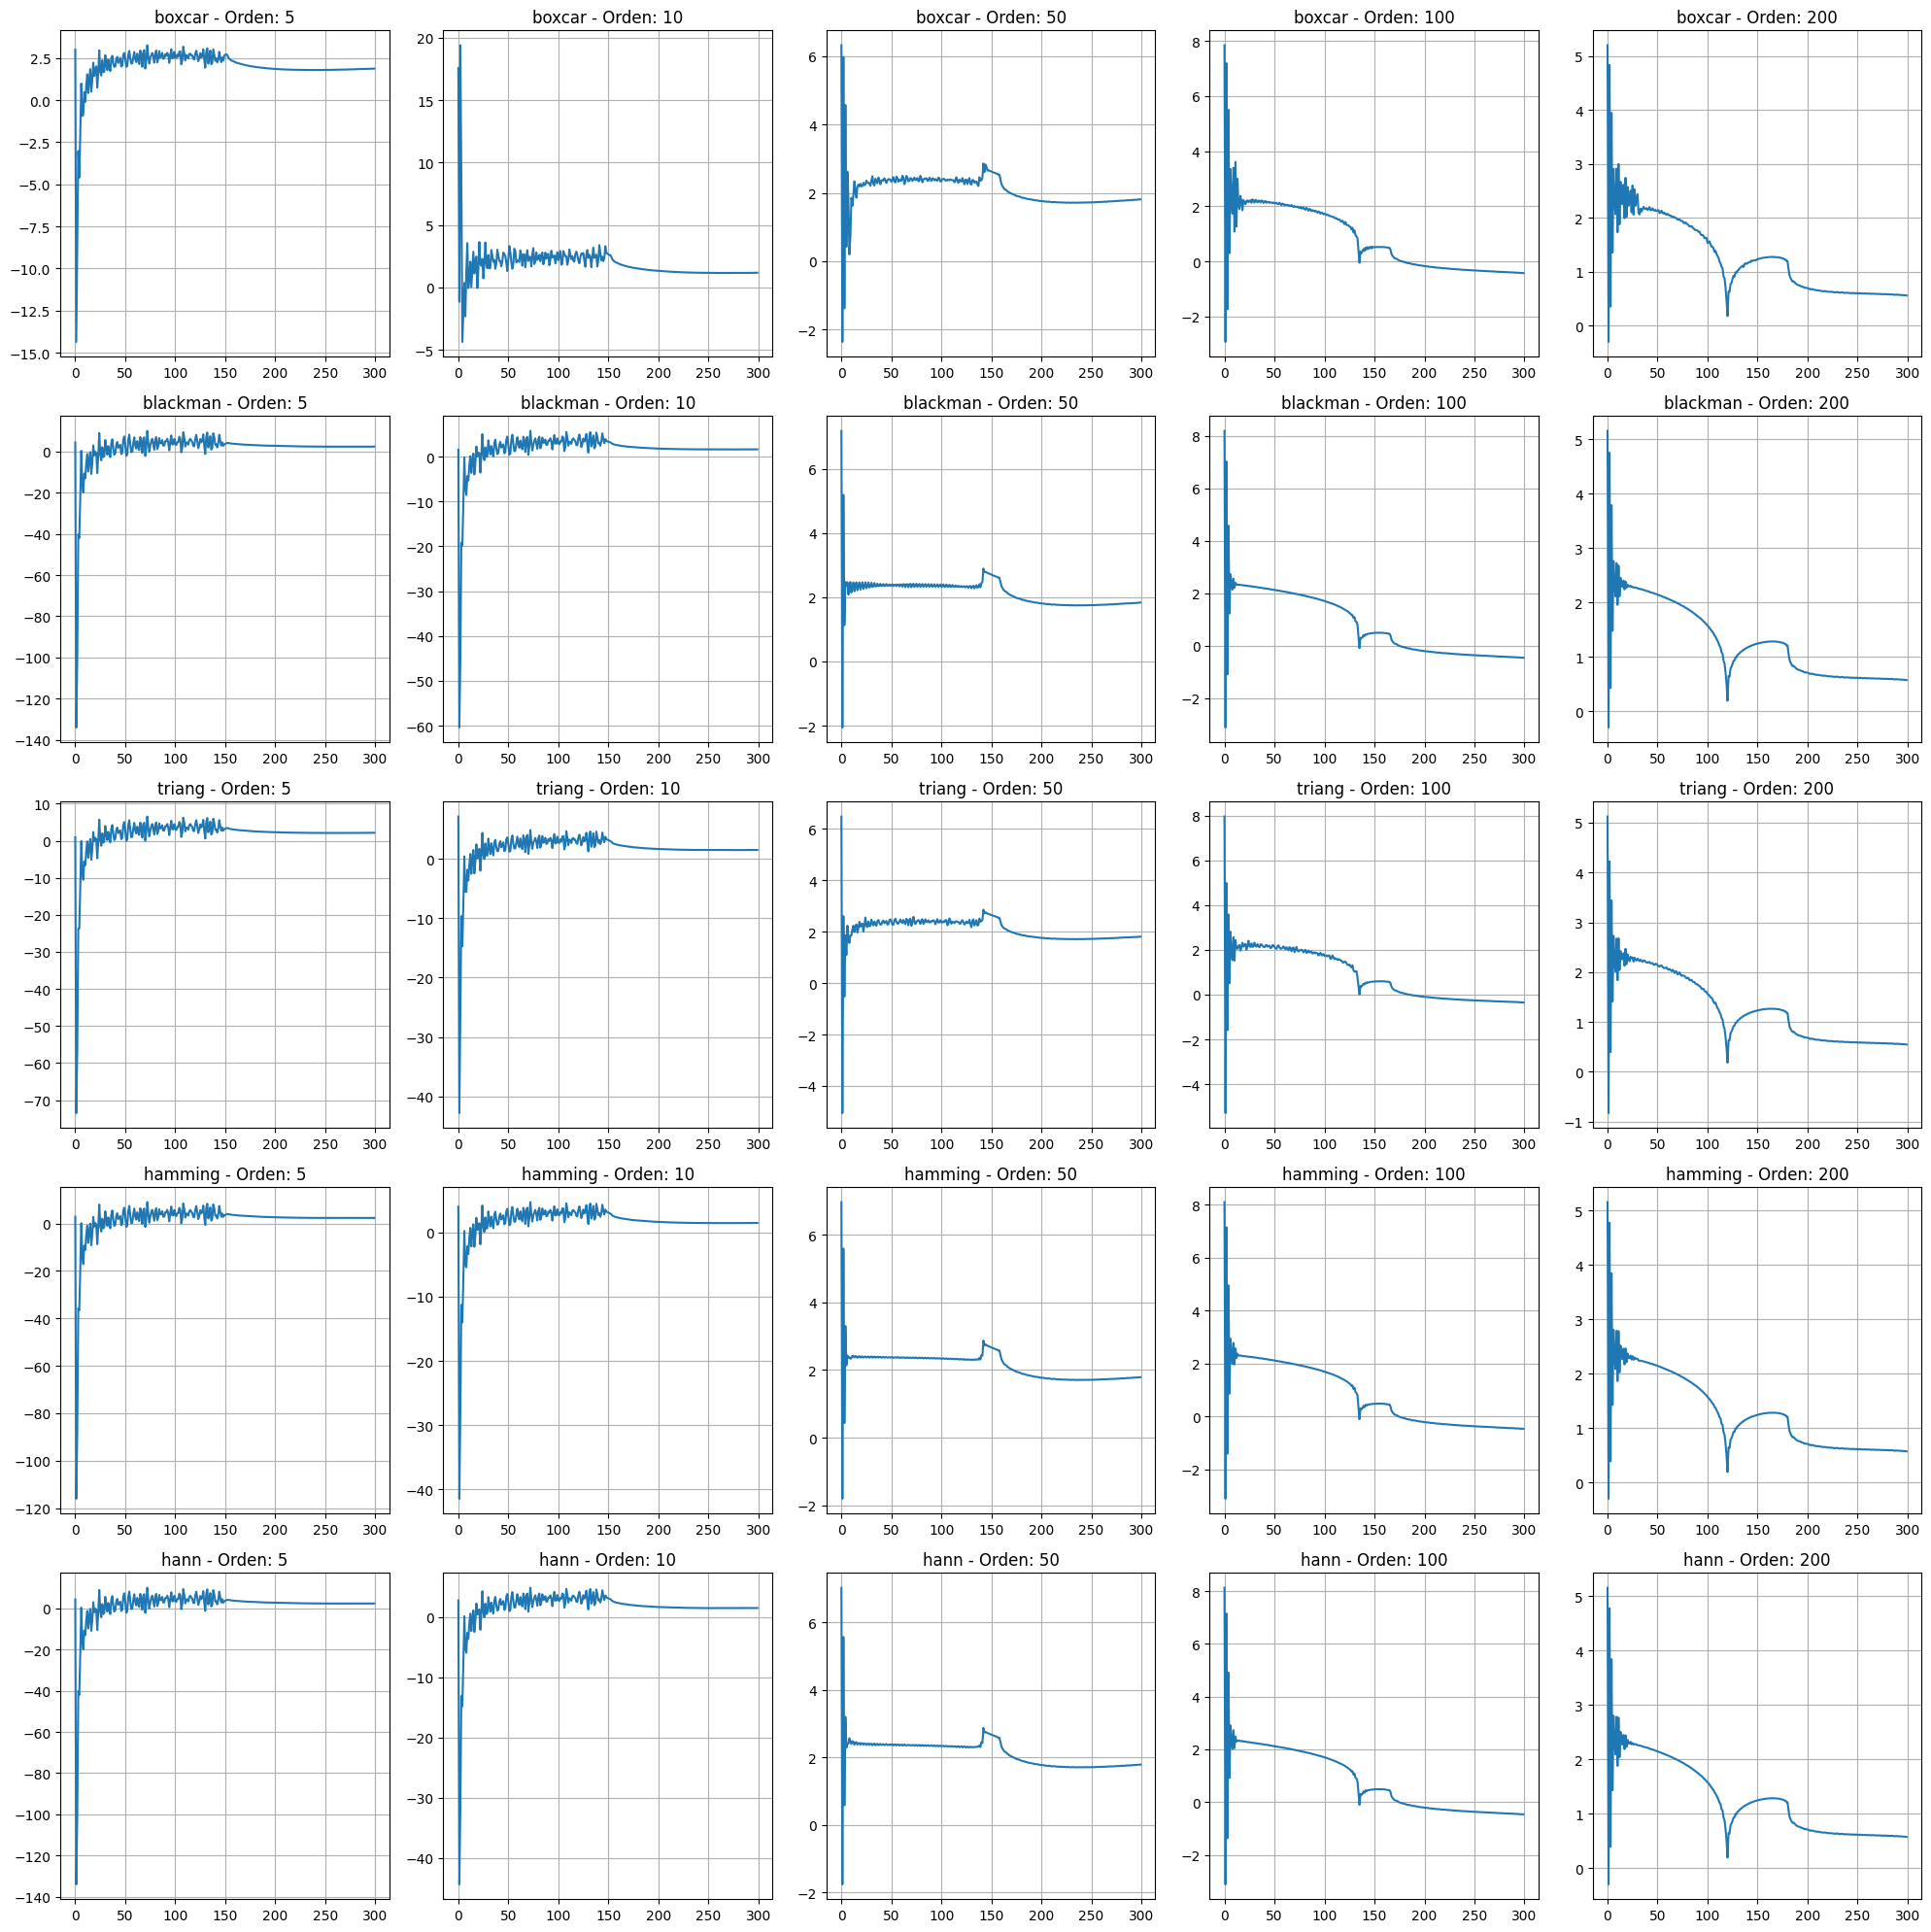

In [54]:
plt.figure(figsize=(20, 20))

seniales_filtradas = []

for i in range(len(ventanas)):
    ventana_nom = ventanas[i]
    
    for j in range(len(Ordenes)):
        orden = Ordenes[j]
        
        filtro = filtros_temporales[i*len(Ordenes) + j]
        senial_filtrada = signal.filtfilt(filtro, [1], seno_comb_ruido, padlen=0)
        seniales_filtradas.append(senial_filtrada)

        # Graficamos
        plt.subplot(len(ventanas), len(Ordenes), i * len(Ordenes) + j + 1)
        plt.title(f"{ventana_nom} - Orden: {orden}")
        plt.plot(senial_filtrada)
        plt.grid(True)

plt.tight_layout()
plt.show()

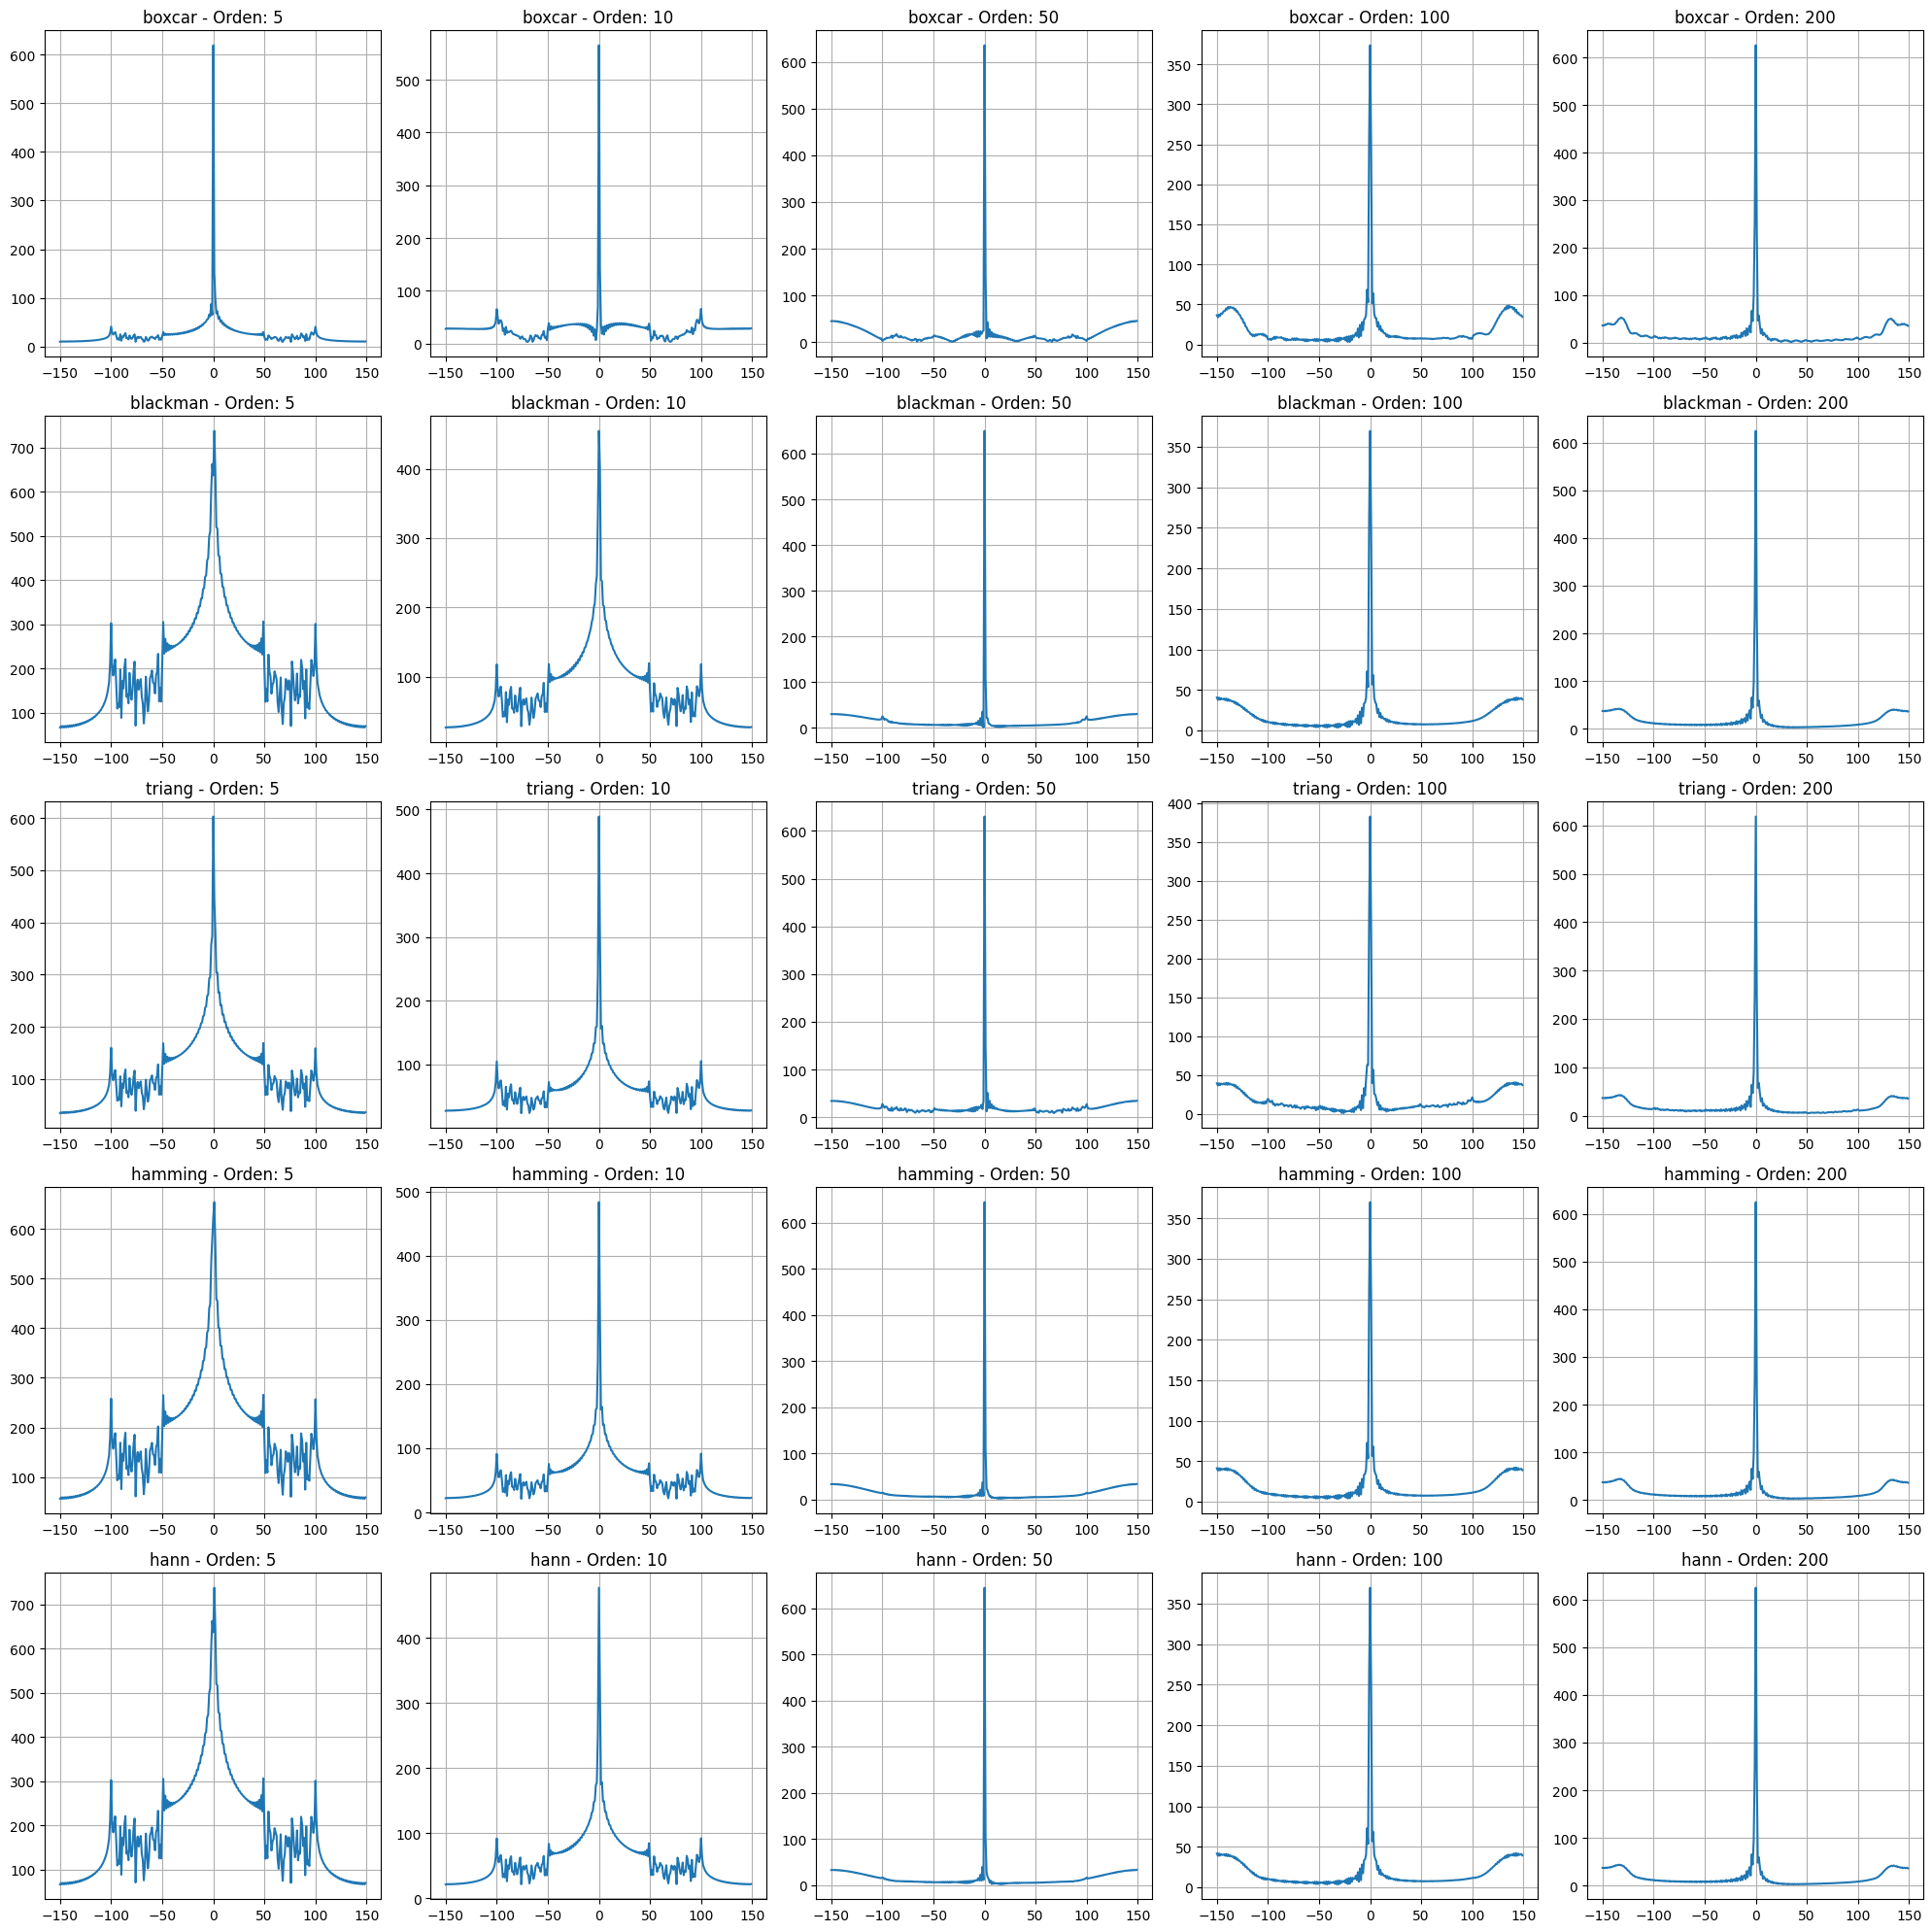

In [55]:
plt.figure(figsize=(20, 20))

for i in range(len(ventanas)):
    ventana_nom = ventanas[i]
    
    for j in range(len(Ordenes)):
        orden = Ordenes[j]

        senial_filtrada = seniales_filtradas[i*len(Ordenes) + j]
        fft_sf = np.fft.fft(senial_filtrada, frecM*duracion)
        norm_fft_sf = np.abs(fft_sf)
        shift_sf = np.fft.fftshift(norm_fft_sf)

        # Graficamos
        plt.subplot(len(ventanas), len(Ordenes), i * len(Ordenes) + j + 1)
        plt.title(f"{ventana_nom} - Orden: {orden}")
        plt.plot(shift_frecs_rc, shift_sf)
        plt.grid(True)

plt.tight_layout()
plt.show()